# <span style="color:darkblue"> Lecture 9 Exercises </span>

<font size = "5">

Import the libraries "matplotlib.pyplot" and "pandas"

In [1]:
# Write your answer here

import matplotlib.pyplot as plt
import pandas as pd

<font size = "5">

In this quiz you will work with data on exchange rates, <br>
for two currencies:

- 1 dollar (USD) to chinese yuan (RMB)
- 1 dollar (USD) to japanese yen (JPY).


<font size = "5">

(a) Import and parse dates

<font size = "3">

- Import the dataset "exchangerates.csv"
- Parse the "date_string" column with ```pd.to_datetime()```



In [3]:
# Write your own code

df = pd.read_csv("data_raw/exchangerates.csv")
df["date"]=pd.to_datetime(df["date_string"])

<font size = "5">

(b) Plot multiple time series

<font size = "3">

- Create a line plot plot which has the "usd_to_rmb" and "usd_to_jpy" on the y-axis <br>
and the date on the x-axis
- Label the x-axis, the y-axis, and the title
- Add a legend and set the names to "1 USD to RMB" and "1 USD to JPY"



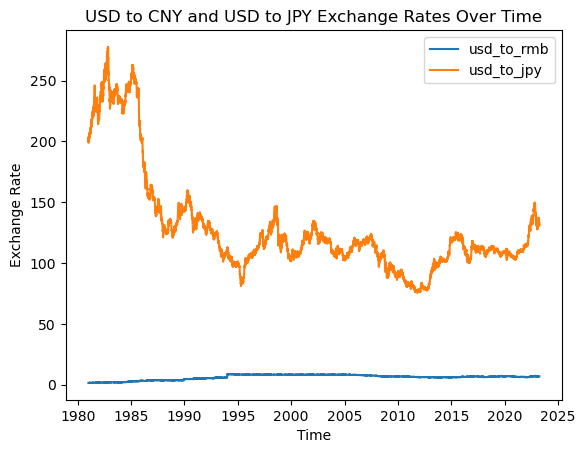

In [4]:
# Write your own code

plt.plot("date", "usd_to_rmb",
          data = df)
plt.plot("date", "usd_to_jpy",
          data = df)
plt.xlabel("Time")
plt.ylabel("Exchange Rate")
plt.title("USD to CNY and USD to JPY Exchange Rates Over Time")
plt.legend()


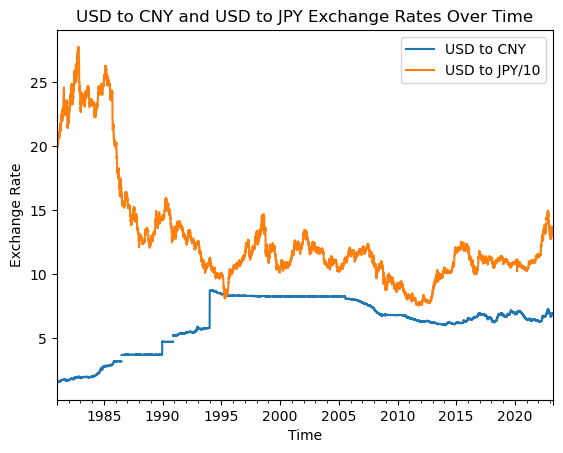

In [ ]:
# Another way
df["usd_to_jpy10"]=df["usd_to_jpy"]/10
df[["date","usd_to_rmb","usd_to_jpy10"]].set_index("date").plot()
plt.xlabel("Time")
plt.ylabel("Exchange Rate")
plt.title("USD to CNY and USD to JPY Exchange Rates Over Time")
plt.legend(["USD to CNY","USD to JPY/10"])

<font size = "5">

(c) Compute growth rates

<font size = "3">

- Calculate a new column "growth_rmb" which computes the percentage daily <br>
growth rate of "usd_to_rmb".



In [ ]:
# ChatGPT's codes

df["growth_rmb"] = df["usd_to_rmb"].pct_change() * 100

C:\Users\Zach\AppData\Local\Temp\ipykernel_14788\3998384382.py:3: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["growth_rmb"] = df["usd_to_rmb"].pct_change() * 100


In [ ]:
# My codes
df["diff_rmb"]=df["usd_to_rmb"].diff()
df["lag_rmb"]=df["usd_to_rmb"].shift(1)
df["growth_rmb2"]=(df["diff_rmb"]/df["lag_rmb"])*100
df[["date", "usd_to_rmb", "growth_rmb","growth_rmb2"]].head(10) # check if results are same

,date,usd_to_rmb,growth_rmb,growth_rmb2
0,1981-01-02,1.5341,NaN,NaN
1,1981-01-05,1.5418,0.501923,0.501923
2,1981-01-06,1.5264,-0.998833,-0.998833
3,1981-01-07,1.5264,0.000000,0.000000
4,1981-01-08,1.5264,0.000000,0.000000
5,1981-01-09,1.5371,0.700996,0.700996
6,1981-01-12,1.5371,0.000000,0.000000
7,1981-01-13,1.5449,0.507449,0.507449
8,1981-01-14,1.5449,0.000000,0.000000
9,1981-01-15,1.5449,0.000000,0.000000


<font size = "5">

(d) Flag subset of data and plot

<font size = "3">

- Create a boolean colum (True/False) "bool_cond" which checks whether <br>
"growth_rmb" had a value greater than 2 or less than -2
- Generate a line plot with the "growth_rmb" series, label the axes and the title
- Use the command ```plt.fill_between()``` to create a shaded region <br>
for time periods where "bool_cond" is true.



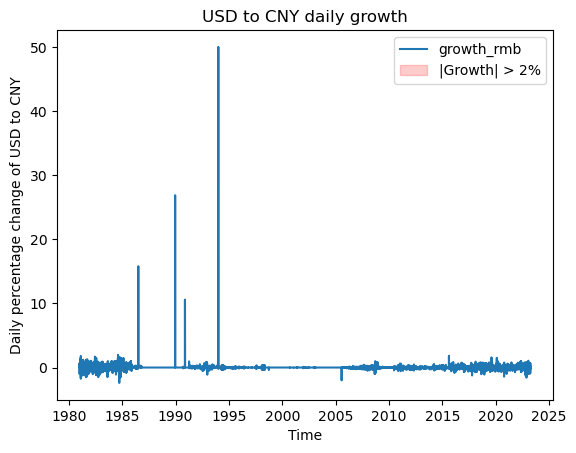

In [19]:
# Write your own code

df["bool_cond"] = (df["growth_rmb"] > 2) | (df["growth_rmb"] < -2)

plt.plot("date", "growth_rmb", data =df)
plt.xlabel("Time")
plt.ylabel("Daily percentage change of USD to CNY")
plt.title("USD to CNY daily growth")
plt.fill_between(x=df["date"], y1=df["growth_rmb"],
                 where=df["bool_cond"], color="red", alpha=0.2,
                 label="|Growth| > 2%")
plt.legend()
plt.show()

<font size = "5">

(e) Aggregate dataset by time period

<font size = "3">

- Create an object "month_config" that uses ```pd.Grouper()```, setting the key to <br>
the date column and freq to "m" (month)
- Compute an aggregate dataset <br>
by month which computes the standard deviation of "usd_to_rmb"
- Display the dataset




In [20]:
# Write your own code

# Define a monthly grouper on the date column
month_config = pd.Grouper(key="date", freq="M")  

# Aggregate by month: std of usd_to_rmb 
monthly_std = (
    df.groupby(month_config)["usd_to_rmb"]
      .agg(std_usd_to_rmb="std", n_obs="count")   # n_obs optional but useful
      .reset_index()
)

# (3) Display
print(monthly_std.head())


        date  std_usd_to_rmb  n_obs
0 1981-01-31        0.019149     21
1 1981-02-28        0.015432     18
2 1981-03-31        0.012636     22
3 1981-04-30        0.017154     22
4 1981-05-31        0.017583     20


C:\Users\Zach\AppData\Local\Temp\ipykernel_14788\2043693779.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  month_config = pd.Grouper(key="date", freq="M")


<font size = "5">

(f) Convert a dataset to long format

<font size = "3">

- Convert the currencies dataset to long format using the following inputs

```
var_name   = "type",
value_name = "exchange_rate",
id_vars    = "date",
value_vars = ["usd_to_rmb","usd_to_jpy"]
```

- Display the dataset


In [21]:
# Write your own code

long_df = pd.melt(
    df,
    id_vars="date",
    value_vars=["usd_to_rmb", "usd_to_jpy"],
    var_name="type",
    value_name="exchange_rate"
)


long_df.head()


,date,type,exchange_rate
0,1981-01-02,usd_to_rmb,1.5341
1,1981-01-05,usd_to_rmb,1.5418
2,1981-01-06,usd_to_rmb,1.5264
3,1981-01-07,usd_to_rmb,1.5264
4,1981-01-08,usd_to_rmb,1.5264
